# SPARTAN vs IMPROVE — shared-parameter comparison

Compares the **SPARTAN** filter network against the US **IMPROVE** network using
only the quantities *both* networks measure on disk in this repo. Parameters that
exist in just one network (e.g. titanium — SPARTAN has it, IMPROVE's local export
does not) are **excluded by design**.

The two networks do **not** share sites, filters, or dates (IMPROVE = rural US,
2003–2015 here; SPARTAN = 4 global urban sites, 2013–2024), so this is a
**distributional + relationship** comparison, not a row-level join — the same
treatment used in `research/improve_hips_offset/`.

### Shared parameters used

| Quantity | SPARTAN `unified_filter_dataset.pkl` | IMPROVE `improve_valid_cleaned.csv` | Units |
|---|---|---|---|
| Elemental Carbon | `ChemSpec_EC_PM2.5` | `ECf_Val` | µg/m³ |
| Organic Carbon | `ChemSpec_OC_PM2.5` | `OCf_Val` | µg/m³ |
| Optical absorption | `HIPS_Fabs` | `fAbs_Val` | Mm⁻¹ |
| Iron | `ChemSpec_Iron_PM2.5` (ng/m³ → ÷1000) | `FEf_Val` | µg/m³ |
| Fine PM₂.₅ mass | `ChemSpec_Filter_PM2.5_mass` | `MF_Val` | µg/m³ |

Derived (computable in both): **OC/EC**, **fAbs/EC** (≈ MAC, m²/g), **Fe/PM₂.₅**.

> **EC methodology note.** SPARTAN stores two non-overlapping filter populations:
> a *ChemSpec* set (thermal `ChemSpec_EC_PM2.5` / `ChemSpec_OC_PM2.5`, metals, PM
> mass) and an *FTIR/HIPS* set (`EC_ftir`, `OC_ftir`, `HIPS_Fabs`). `HIPS_Fabs`
> only co-occurs with `EC_ftir`. So distributions and OC/EC use thermal
> `ChemSpec_EC` (the closer analog to IMPROVE's thermal-optical `ECf`), while the
> **fAbs-vs-EC and fAbs/EC (MAC)** analyses are forced to use `EC_ftir` on the
> SPARTAN side. The FTIR-vs-thermal EC difference is a known sensitivity — read
> the MAC slope with that caveat.

**Outputs** are written under `research/spartan/improve_comparison/{figures,tables}/`.


## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "AGENTS.md").exists() and (cand / "research").exists():
            return cand
    raise RuntimeError("Could not locate repo root (AGENTS.md). CWD=%s" % Path.cwd())


REPO_ROOT = find_repo_root()
print("Repo root:", REPO_ROOT)

# Honour AGENTS.md: white-background plotting default + the shared regression helper.
sys.path.insert(0, str(REPO_ROOT / "research/ftir_hips_chem/scripts"))
try:
    from plotting import apply_default_style
    from plotting.utils import calculate_regression_stats
    apply_default_style()
    print("Applied plotting.apply_default_style()")
except Exception as e:  # pragma: no cover - notebook still runs standalone
    print("plotting package unavailable (%s); using local fallbacks" % e)

    def calculate_regression_stats(x, y):
        x = np.asarray(x, float); y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 3:
            return None
        slope, intercept = np.polyfit(x, y, 1)
        r = np.corrcoef(x, y)[0, 1]
        return {"n": len(x), "slope": slope, "intercept": intercept,
                "r_squared": r ** 2, "correlation": r}

# Paths
SPARTAN_PKL = REPO_ROOT / "research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl"
IMPROVE_CSV = REPO_ROOT / "research/ftir_hips_chem/output/improve_high_fabs_comparison/improve_valid_cleaned.csv"

OUT = REPO_ROOT / "research/spartan/improve_comparison"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colours: network is the primary grouping.
NET_COLORS = {"SPARTAN": "#C0392B", "IMPROVE": "#2E86C1"}
SPARTAN_SITE_COLORS = {"CHTS": "#8E44AD", "ETAD": "#E67E22",
                       "INDH": "#16A085", "USPA": "#2C3E50"}

# The shared schema: harmonized column -> (pretty label, unit, log-scale?)
SHARED = {
    "EC_ugm3":   ("Elemental Carbon", "µg/m³", True),
    "OC_ugm3":   ("Organic Carbon",   "µg/m³", True),
    "Fabs_Mm":   ("Absorption fAbs",  "Mm⁻¹",  True),
    "Fe_ugm3":   ("Iron",             "µg/m³", True),
    "PM25_ugm3": ("Fine PM₂.₅ mass",  "µg/m³", True),
}
SCATTER_SAMPLE = 6000  # cap points drawn per network in scatters (fit uses all)
RNG = np.random.default_rng(0)
print("Figures ->", FIG_DIR)
print("Tables  ->", TAB_DIR)


Repo root: /Users/ahmadjalil/github/aethmodular
Applied plotting.apply_default_style()
Figures -> /Users/ahmadjalil/github/aethmodular/research/spartan/improve_comparison/figures
Tables  -> /Users/ahmadjalil/github/aethmodular/research/spartan/improve_comparison/tables


## 1. Load and harmonize

SPARTAN is stored long (one row per filter × parameter) — pivot to one row per
filter, then rename the shared parameters into a common schema and convert iron
from ng/m³ to µg/m³. IMPROVE is already filter-level wide.

In [2]:
# --- SPARTAN: long -> wide -> harmonized ---
sp_long = pd.read_pickle(SPARTAN_PKL)
sp_long["SampleDate"] = pd.to_datetime(sp_long["SampleDate"], errors="coerce")

sp_params = [
    "ChemSpec_EC_PM2.5", "ChemSpec_OC_PM2.5", "HIPS_Fabs", "EC_ftir",
    "ChemSpec_Iron_PM2.5", "ChemSpec_Filter_PM2.5_mass",
]
sp_wide = (
    sp_long[sp_long["Parameter"].isin(sp_params)]
    .pivot_table(index=["Site", "FilterId", "SampleDate"],
                 columns="Parameter", values="Concentration", aggfunc="first")
    .reset_index()
)

spartan = pd.DataFrame({
    "network":      "SPARTAN",
    "site":         sp_wide["Site"],
    "date":         sp_wide["SampleDate"],
    "EC_ugm3":      sp_wide.get("ChemSpec_EC_PM2.5"),     # thermal — for distributions/OC-EC
    "OC_ugm3":      sp_wide.get("ChemSpec_OC_PM2.5"),
    "Fabs_Mm":      sp_wide.get("HIPS_Fabs"),
    "EC_ftir_ugm3": sp_wide.get("EC_ftir"),               # FTIR — the EC co-measured with fAbs
    "Fe_ugm3":      sp_wide.get("ChemSpec_Iron_PM2.5") / 1000.0,  # ng/m³ -> µg/m³
    "PM25_ugm3":    sp_wide.get("ChemSpec_Filter_PM2.5_mass"),
})
print("SPARTAN filters:", len(spartan), "| sites:", sorted(spartan["site"].unique()))
spartan.head()


SPARTAN filters: 1450 | sites: ['CHTS', 'ETAD', 'INDH', 'USPA']


,network,site,date,EC_ugm3,OC_ugm3,Fabs_Mm,EC_ftir_ugm3,Fe_ugm3,PM25_ugm3
0,SPARTAN,CHTS,2013-09-02,NaN,NaN,NaN,NaN,NaN,67.20
1,SPARTAN,CHTS,2013-09-03,NaN,NaN,NaN,NaN,NaN,80.70
2,SPARTAN,CHTS,2013-09-04,NaN,NaN,NaN,NaN,NaN,18.65
3,SPARTAN,CHTS,2013-09-06,NaN,NaN,NaN,NaN,NaN,57.89
4,SPARTAN,CHTS,2013-09-08,NaN,NaN,NaN,NaN,NaN,58.89


In [3]:
# --- IMPROVE: already wide -> harmonized ---
imp_cols = ["SiteCode", "Date", "ECf_Val", "OCf_Val", "fAbs_Val", "FEf_Val", "MF_Val"]
imp = pd.read_csv(IMPROVE_CSV, usecols=lambda c: c in set(imp_cols),
                  parse_dates=["Date"], low_memory=False)

improve = pd.DataFrame({
    "network":      "IMPROVE",
    "site":         imp["SiteCode"],
    "date":         imp["Date"],
    "EC_ugm3":      imp["ECf_Val"],
    "OC_ugm3":      imp["OCf_Val"],
    "Fabs_Mm":      imp["fAbs_Val"],
    "EC_ftir_ugm3": imp["ECf_Val"],   # IMPROVE has a single (thermal-optical) EC
    "Fe_ugm3":      imp["FEf_Val"],
    "PM25_ugm3":    imp["MF_Val"],
})
print("IMPROVE rows:", len(improve), "| sites:", improve["site"].nunique())
improve.head()


IMPROVE rows: 379697 | sites: 214


,network,site,date,EC_ugm3,OC_ugm3,Fabs_Mm,EC_ftir_ugm3,Fe_ugm3,PM25_ugm3
0,IMPROVE,BIRM1,2005-07-24,2.6324,7.5017,12.86,2.6324,NaN,38.2202
1,IMPROVE,CABA1,2005-06-15,0.0655,0.0900,0.61,0.0655,NaN,0.7829
2,IMPROVE,CACO1,2005-01-13,0.2468,0.7252,2.24,0.2468,NaN,4.0682
3,IMPROVE,CACR1,2005-12-21,0.6859,1.8910,4.79,0.6859,NaN,15.7771
4,IMPROVE,CACR1,2005-12-24,0.2039,0.7531,2.19,0.2039,NaN,3.1948


In [4]:
# --- Combine + derived ratios ---
both = pd.concat([spartan, improve], ignore_index=True)

# Ratios only where the denominator is meaningfully positive.
ec_ok = both["EC_ugm3"] > 0
pm_ok = both["PM25_ugm3"] > 0
ecf_ok = both["EC_ftir_ugm3"] > 0
both["OC_EC"]   = np.where(ec_ok, both["OC_ugm3"] / both["EC_ugm3"], np.nan)
# MAC pairs fAbs with the EC measured on the SAME filter (EC_ftir for SPARTAN).
both["Fabs_EC"] = np.where(ecf_ok, both["Fabs_Mm"] / both["EC_ftir_ugm3"], np.nan)  # ≈ MAC (m²/g)
both["Fe_PM"]   = np.where(pm_ok, 100 * both["Fe_ugm3"] / both["PM25_ugm3"], np.nan)  # % of PM2.5

print(both.groupby("network").size().rename("rows").to_string())
both.head()


network
IMPROVE    379697
SPARTAN      1450


,network,site,date,EC_ugm3,OC_ugm3,Fabs_Mm,EC_ftir_ugm3,Fe_ugm3,PM25_ugm3,OC_EC,Fabs_EC,Fe_PM
0,SPARTAN,CHTS,2013-09-02,NaN,NaN,NaN,NaN,NaN,67.20,NaN,NaN,NaN
1,SPARTAN,CHTS,2013-09-03,NaN,NaN,NaN,NaN,NaN,80.70,NaN,NaN,NaN
2,SPARTAN,CHTS,2013-09-04,NaN,NaN,NaN,NaN,NaN,18.65,NaN,NaN,NaN
3,SPARTAN,CHTS,2013-09-06,NaN,NaN,NaN,NaN,NaN,57.89,NaN,NaN,NaN
4,SPARTAN,CHTS,2013-09-08,NaN,NaN,NaN,NaN,NaN,58.89,NaN,NaN,NaN


## 2. Coverage and the shared-parameter map

How much usable data each network contributes per shared parameter, plus a
machine-readable record of exactly what was mapped to what.

In [5]:
# Shared-parameter map (also saved to disk)
map_rows = [
    ("EC_ugm3",   "Elemental Carbon", "ChemSpec_EC_PM2.5",          "ECf_Val",  "µg/m³", "direct"),
    ("OC_ugm3",   "Organic Carbon",   "ChemSpec_OC_PM2.5",          "OCf_Val",  "µg/m³", "direct"),
    ("Fabs_Mm",   "Absorption fAbs",  "HIPS_Fabs",                  "fAbs_Val", "Mm⁻¹",  "direct"),
    ("Fe_ugm3",   "Iron",             "ChemSpec_Iron_PM2.5",        "FEf_Val",  "µg/m³", "SPARTAN ng/m³ ÷ 1000"),
    ("PM25_ugm3", "Fine PM2.5 mass",  "ChemSpec_Filter_PM2.5_mass", "MF_Val",   "µg/m³", "direct"),
    ("EC_ftir_ugm3", "EC paired with fAbs", "EC_ftir",              "ECf_Val",  "µg/m³",
     "SPARTAN FTIR EC (only EC co-measured with HIPS_Fabs); used for fAbs~EC & MAC"),
]
shared_map = pd.DataFrame(map_rows, columns=[
    "harmonized_col", "quantity", "spartan_param", "improve_col", "units", "note"])
shared_map.to_csv(TAB_DIR / "shared_parameter_map.csv", index=False)
shared_map


,harmonized_col,quantity,spartan_param,improve_col,units,note
0,EC_ugm3,Elemental Carbon,ChemSpec_EC_PM2.5,ECf_Val,µg/m³,direct
1,OC_ugm3,Organic Carbon,ChemSpec_OC_PM2.5,OCf_Val,µg/m³,direct
2,Fabs_Mm,Absorption fAbs,HIPS_Fabs,fAbs_Val,Mm⁻¹,direct
3,Fe_ugm3,Iron,ChemSpec_Iron_PM2.5,FEf_Val,µg/m³,SPARTAN ng/m³ ÷ 1000
4,PM25_ugm3,Fine PM2.5 mass,ChemSpec_Filter_PM2.5_mass,MF_Val,µg/m³,direct
5,EC_ftir_ugm3,EC paired with fAbs,EC_ftir,ECf_Val,µg/m³,SPARTAN FTIR EC (only EC co-measured with HIPS...


In [6]:
# Per-network, per-parameter coverage
cov = []
for net, g in both.groupby("network"):
    for col, (label, unit, _) in SHARED.items():
        s = g[col].dropna()
        d = g.loc[s.index, "date"]
        cov.append({
            "network": net, "quantity": label, "column": col, "units": unit,
            "n": int(s.shape[0]), "n_sites": g.loc[s.index, "site"].nunique(),
            "date_min": d.min(), "date_max": d.max(),
            "median": round(float(s.median()), 4) if len(s) else np.nan,
        })
coverage = pd.DataFrame(cov)
coverage.to_csv(TAB_DIR / "coverage_summary.csv", index=False)
coverage


,network,quantity,column,units,n,n_sites,date_min,date_max,median
0,IMPROVE,Elemental Carbon,EC_ugm3,µg/m³,379697,214,2003-01-03,2025-07-30,0.1213
1,IMPROVE,Organic Carbon,OC_ugm3,µg/m³,379697,214,2003-01-03,2025-07-30,0.6778
2,IMPROVE,Absorption fAbs,Fabs_Mm,Mm⁻¹,379697,214,2003-01-03,2025-07-30,1.5102
3,IMPROVE,Iron,Fe_ugm3,µg/m³,379658,214,2003-01-03,2025-07-30,0.0223
4,IMPROVE,Fine PM₂.₅ mass,PM25_ugm3,µg/m³,379367,213,2003-01-03,2025-07-30,3.4786
5,SPARTAN,Elemental Carbon,EC_ugm3,µg/m³,543,4,2019-05-08,2024-10-06,1.5300
6,SPARTAN,Organic Carbon,OC_ugm3,µg/m³,543,4,2019-05-08,2024-10-06,3.6800
7,SPARTAN,Absorption fAbs,Fabs_Mm,Mm⁻¹,546,4,2022-07-05,2024-12-08,18.6188
8,SPARTAN,Iron,Fe_ugm3,µg/m³,819,4,2013-09-10,2024-10-06,0.2369
9,SPARTAN,Fine PM₂.₅ mass,PM25_ugm3,µg/m³,853,4,2013-06-28,2024-10-06,17.3300


## 3. Distribution comparison

Where do the two networks sit for each shared parameter? Boxplots (log y) give
the spread; CDFs make the network offset easy to read. Negative below-MDL values
are kept for boxplots but dropped for the log-scale CDFs.

/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3299963775.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3299963775.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3299963775.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers

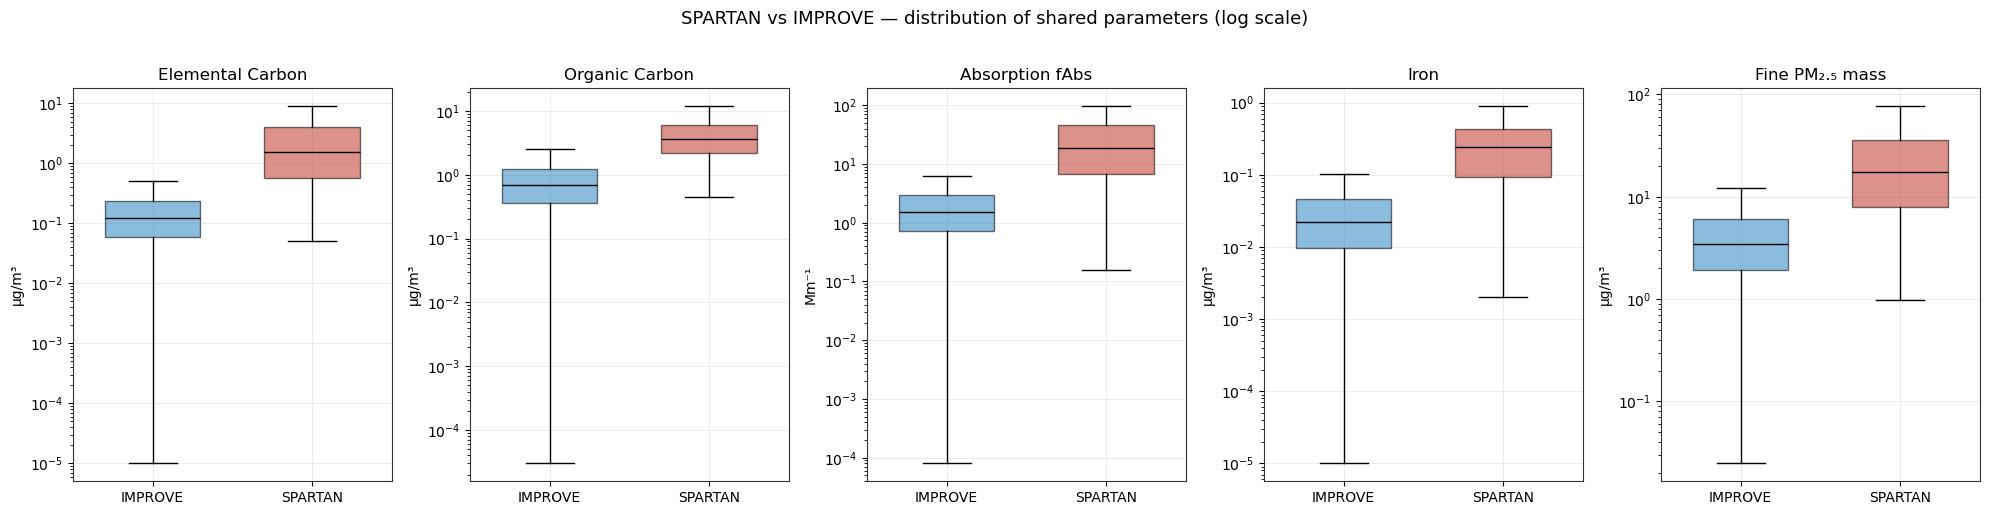

In [7]:
def _pos(s):
    return s[np.isfinite(s) & (s > 0)]

# 3a. Network-level boxplots (log scale)
fig, axes = plt.subplots(1, len(SHARED), figsize=(4 * len(SHARED), 5))
for ax, (col, (label, unit, logy)) in zip(axes, SHARED.items()):
    data, labels, colors = [], [], []
    for net in ["IMPROVE", "SPARTAN"]:
        vals = _pos(both.loc[both.network == net, col])
        if len(vals):
            data.append(vals.values); labels.append(net); colors.append(NET_COLORS[net])
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_yscale("log")
    ax.set_title(label); ax.set_ylabel(unit)
fig.suptitle("SPARTAN vs IMPROVE — distribution of shared parameters (log scale)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_distribution_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


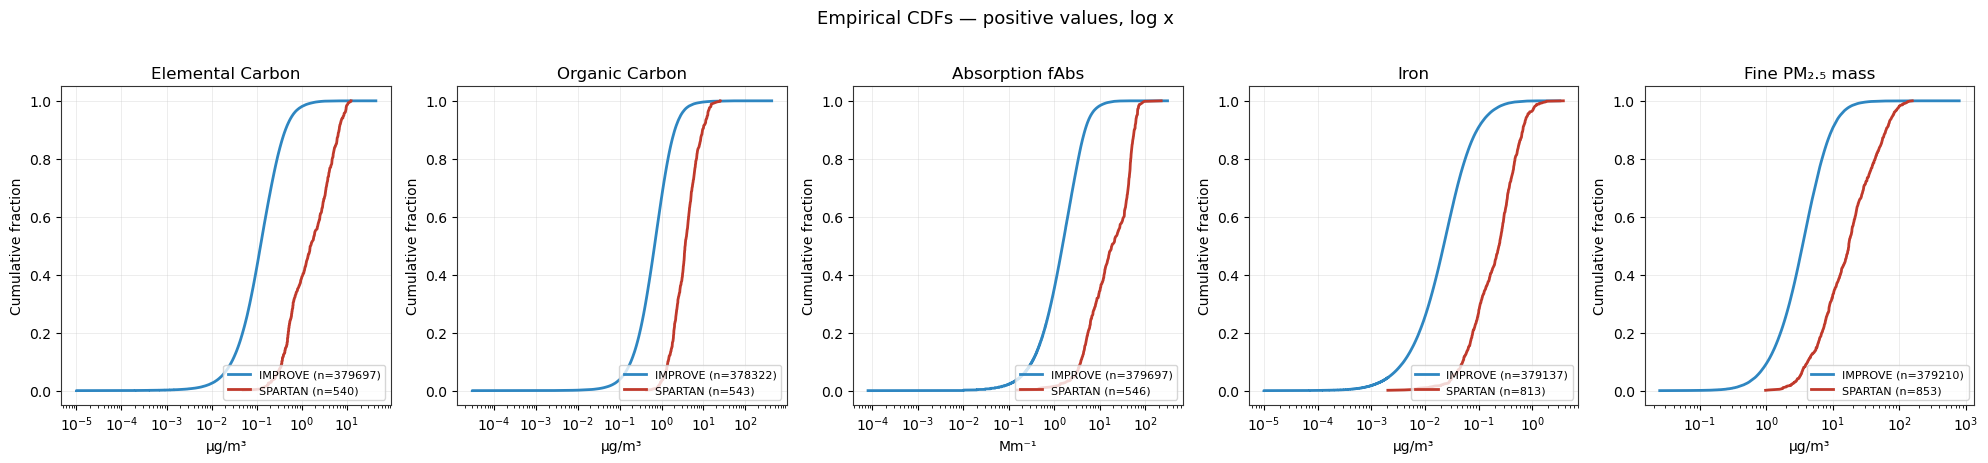

In [8]:
# 3b. CDF overlays (log x)
fig, axes = plt.subplots(1, len(SHARED), figsize=(4 * len(SHARED), 4.5))
for ax, (col, (label, unit, logx)) in zip(axes, SHARED.items()):
    for net in ["IMPROVE", "SPARTAN"]:
        vals = _pos(both.loc[both.network == net, col]).sort_values().values
        if len(vals) < 3:
            continue
        y = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, y, color=NET_COLORS[net], lw=2, label=f"{net} (n={len(vals)})")
    ax.set_xscale("log")
    ax.set_title(label); ax.set_xlabel(unit); ax.set_ylabel("Cumulative fraction")
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Empirical CDFs — positive values, log x", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_distribution_cdf.png", dpi=120, bbox_inches="tight")
plt.show()


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3890440840.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3890440840.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3890440840.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3890440840.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/3890440840.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)


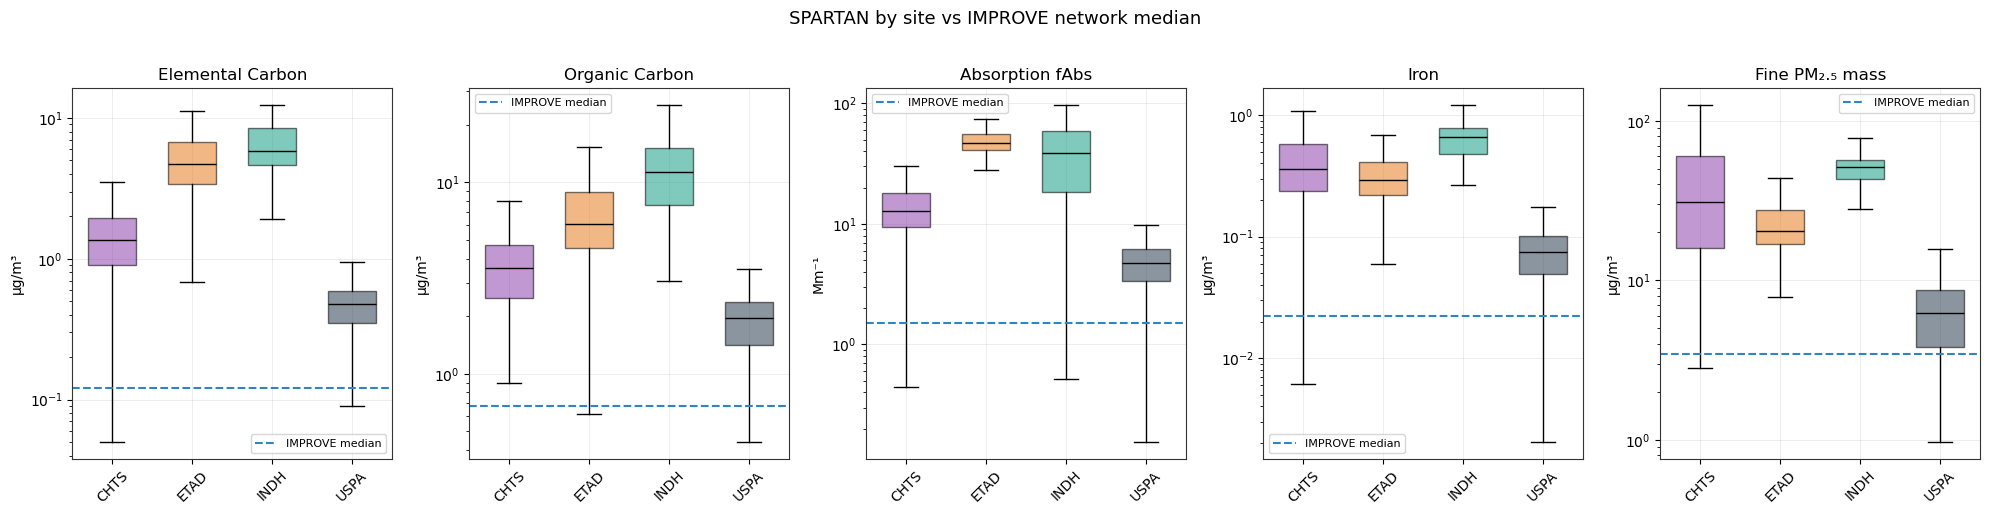

In [9]:
# 3c. SPARTAN per-site context (the 4 sites individually vs the IMPROVE median)
fig, axes = plt.subplots(1, len(SHARED), figsize=(4 * len(SHARED), 5))
sp_sites = sorted(spartan["site"].unique())
for ax, (col, (label, unit, _)) in zip(axes, SHARED.items()):
    data, labels, colors = [], [], []
    for site in sp_sites:
        vals = _pos(both.loc[(both.network == "SPARTAN") & (both.site == site), col])
        if len(vals):
            data.append(vals.values); labels.append(site)
            colors.append(SPARTAN_SITE_COLORS.get(site, "#888"))
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    imp_med = _pos(both.loc[both.network == "IMPROVE", col]).median()
    if np.isfinite(imp_med):
        ax.axhline(imp_med, color=NET_COLORS["IMPROVE"], ls="--", lw=1.5,
                   label="IMPROVE median")
    ax.set_yscale("log"); ax.set_title(label); ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=45); ax.legend(fontsize=8)
fig.suptitle("SPARTAN by site vs IMPROVE network median", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_spartan_site_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


In [10]:
# 3d. Distribution statistics table
def describe(s):
    s = s.dropna()
    if not len(s):
        return dict(n=0)
    q = s.quantile([.05, .25, .5, .75, .95])
    return dict(n=int(len(s)), mean=round(s.mean(), 4), std=round(s.std(), 4),
                p05=round(q[.05], 4), p25=round(q[.25], 4), median=round(q[.5], 4),
                p75=round(q[.75], 4), p95=round(q[.95], 4),
                min=round(s.min(), 4), max=round(s.max(), 4))

rows = []
for net, g in both.groupby("network"):
    for col, (label, unit, _) in SHARED.items():
        rows.append({"network": net, "quantity": label, "units": unit, **describe(g[col])})
dist_stats = pd.DataFrame(rows)
dist_stats.to_csv(TAB_DIR / "distribution_stats.csv", index=False)
dist_stats


,network,quantity,units,n,mean,std,p05,p25,median,p75,p95,min,max
0,IMPROVE,Elemental Carbon,µg/m³,379697,0.2053,0.3650,0.0166,0.0592,0.1213,0.2407,0.6215,0.0000,43.7604
1,IMPROVE,Organic Carbon,µg/m³,379697,1.0395,1.8187,0.1128,0.3540,0.6778,1.2347,2.8673,-0.1717,428.1492
2,IMPROVE,Absorption fAbs,Mm⁻¹,379697,2.2435,2.6010,0.1900,0.7100,1.5102,2.9400,6.3800,0.0001,310.9500
3,IMPROVE,Iron,µg/m³,379658,0.0422,0.0691,0.0022,0.0098,0.0223,0.0467,0.1468,-0.0017,3.2604
4,IMPROVE,Fine PM₂.₅ mass,µg/m³,379367,4.7878,5.3050,0.7060,1.9161,3.4786,6.0035,12.8742,-10.7222,794.9835
5,SPARTAN,Elemental Carbon,µg/m³,543,2.6687,2.6612,0.2600,0.5650,1.5300,3.9750,8.5370,-0.9400,12.3300
6,SPARTAN,Organic Carbon,µg/m³,543,4.7643,3.6471,1.1320,2.1850,3.6800,6.0600,12.6860,0.4400,25.3600
7,SPARTAN,Absorption fAbs,Mm⁻¹,546,27.2298,23.4938,2.8722,6.6563,18.6188,45.4925,66.0085,0.1553,225.5183
8,SPARTAN,Iron,µg/m³,819,0.3077,0.3045,0.0315,0.0936,0.2368,0.4278,0.8183,0.0000,3.7958
9,SPARTAN,Fine PM₂.₅ mass,µg/m³,853,26.1778,25.6773,3.2320,7.8900,17.3300,35.5000,80.2320,0.9700,156.2700


## 4. Relationship bridge

The networks share no filters, but they share *physics*. Comparing the slope of
key relationships is the real bridge:

- **fAbs vs EC** — the absorption-per-carbon (effective MAC). This is the heart of
  the existing `improve_hips_offset` work.
- **OC vs EC** — carbon mix / combustion regime.
- **Fe vs PM₂.₅** — crustal/dust loading as a fraction of mass.

Reported with **R²** and slope per AGENTS.md (R² preferred over raw r).

For **fAbs vs EC** the SPARTAN x-axis is `EC_ftir` (the only EC on the same filters
as `HIPS_Fabs`); IMPROVE uses its single thermal-optical `ECf`. The other two
relationships use thermal/ChemSpec quantities on both sides.

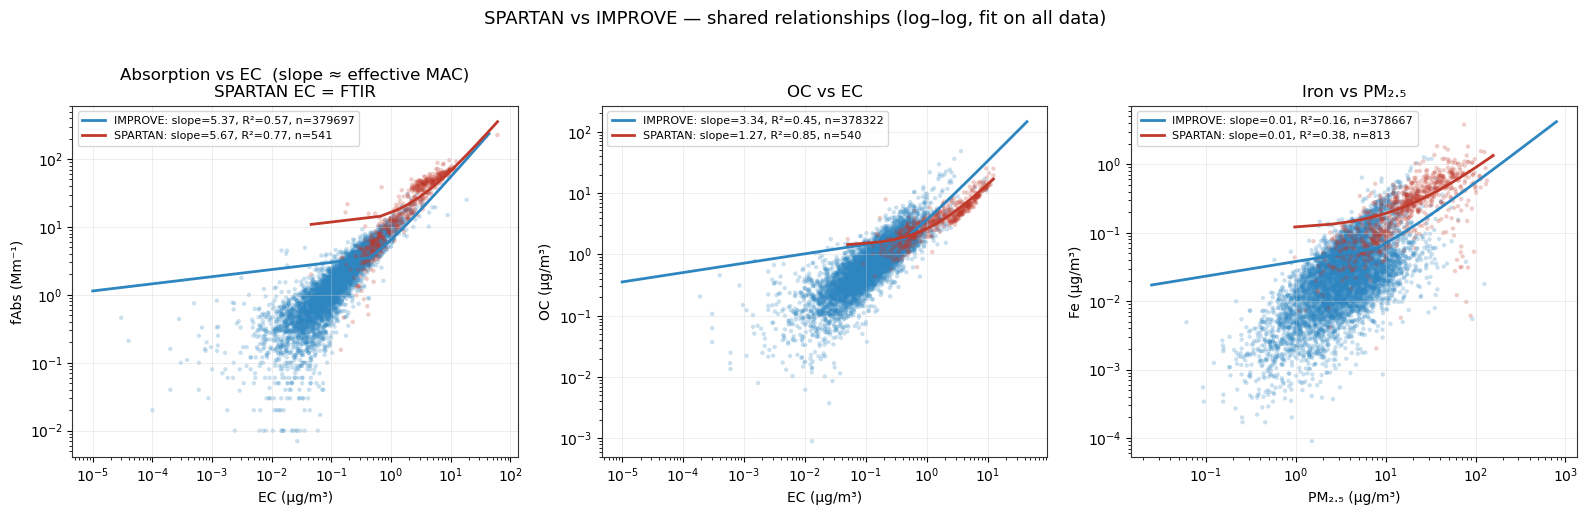

,relationship,network,n,slope,intercept,r_squared,correlation
0,Fabs_Mm~EC_ftir_ugm3,IMPROVE,379697,5.3674,1.1418,0.5673,0.7532
1,Fabs_Mm~EC_ftir_ugm3,SPARTAN,541,5.6700,10.6393,0.7726,0.8790
2,OC_ugm3~EC_ugm3,IMPROVE,378322,3.3366,0.3561,0.4484,0.6697
3,OC_ugm3~EC_ugm3,SPARTAN,540,1.2653,1.3826,0.8494,0.9216
4,Fe_ugm3~PM25_ugm3,IMPROVE,378667,0.0053,0.0171,0.1626,0.4032
5,Fe_ugm3~PM25_ugm3,SPARTAN,813,0.0078,0.1138,0.3846,0.6202


In [11]:
def scatter_fit(ax, xcol, ycol, xlabel, ylabel, log=True):
    fits = []
    for net in ["IMPROVE", "SPARTAN"]:
        g = both[both.network == net][[xcol, ycol]].dropna()
        if log:
            g = g[(g[xcol] > 0) & (g[ycol] > 0)]
        if len(g) < 3:
            continue
        st = calculate_regression_stats(g[xcol].values, g[ycol].values)
        # plot a capped sample, fit on all
        gp = g.sample(min(SCATTER_SAMPLE, len(g)), random_state=0)
        ax.scatter(gp[xcol], gp[ycol], s=10, alpha=0.25,
                   color=NET_COLORS[net], edgecolors="none", label=None)
        xs = np.linspace(g[xcol].min(), g[xcol].max(), 100)
        ax.plot(xs, st["slope"] * xs + st["intercept"], color=NET_COLORS[net], lw=2,
                label=f"{net}: slope={st['slope']:.2f}, R²={st['r_squared']:.2f}, n={st['n']}")
        fits.append({"relationship": f"{ycol}~{xcol}", "network": net, **st})
    if log:
        ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    return fits

all_fits = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
all_fits += scatter_fit(axes[0], "EC_ftir_ugm3", "Fabs_Mm",
                        "EC (µg/m³)", "fAbs (Mm⁻¹)")
axes[0].set_title("Absorption vs EC  (slope ≈ effective MAC)\nSPARTAN EC = FTIR")
all_fits += scatter_fit(axes[1], "EC_ugm3", "OC_ugm3",
                        "EC (µg/m³)", "OC (µg/m³)")
axes[1].set_title("OC vs EC")
all_fits += scatter_fit(axes[2], "PM25_ugm3", "Fe_ugm3",
                        "PM₂.₅ (µg/m³)", "Fe (µg/m³)")
axes[2].set_title("Iron vs PM₂.₅")
fig.suptitle("SPARTAN vs IMPROVE — shared relationships (log–log, fit on all data)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_relationship_bridge.png", dpi=120, bbox_inches="tight")
plt.show()

rel_fits = pd.DataFrame(all_fits)[
    ["relationship", "network", "n", "slope", "intercept", "r_squared", "correlation"]
].round(4)
rel_fits.to_csv(TAB_DIR / "relationship_fits.csv", index=False)
rel_fits


## 5. Derived ratio comparison

Ratios are network-independent and dimensionless-ish, so they compare cleanly:
**OC/EC** (combustion mix), **fAbs/EC** (effective MAC, m²/g), **Fe/PM₂.₅** (% crustal).

/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/240579387.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/240579387.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_99199/240579387.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=Fa

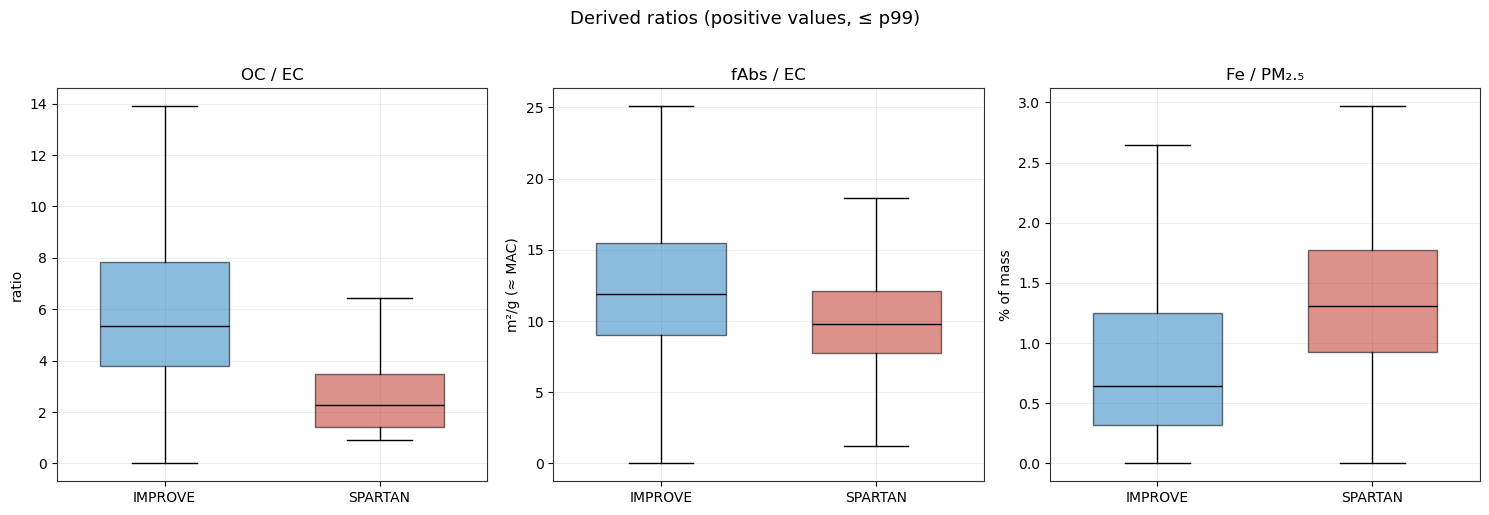

,network,ratio,unit,n,median,p25,p75
0,IMPROVE,OC / EC,ratio,374525,5.348,3.774,7.825
1,SPARTAN,OC / EC,ratio,534,2.267,1.406,3.472
2,IMPROVE,fAbs / EC,m²/g (≈ MAC),375900,11.906,9.018,15.446
3,SPARTAN,fAbs / EC,m²/g (≈ MAC),535,9.790,7.732,12.108
4,IMPROVE,Fe / PM₂.₅,% of mass,374875,0.641,0.322,1.253
5,SPARTAN,Fe / PM₂.₅,% of mass,804,1.306,0.927,1.770


In [12]:
ratios = {
    "OC_EC":   ("OC / EC", "ratio"),
    "Fabs_EC": ("fAbs / EC", "m²/g (≈ MAC)"),
    "Fe_PM":   ("Fe / PM₂.₅", "% of mass"),
}
# clip to sensible positive percentiles so a few extremes don't crush the boxes
fig, axes = plt.subplots(1, len(ratios), figsize=(5 * len(ratios), 5))
rows = []
for ax, (col, (label, unit)) in zip(axes, ratios.items()):
    data, labels, colors = [], [], []
    for net in ["IMPROVE", "SPARTAN"]:
        vals = both.loc[both.network == net, col].dropna()
        vals = vals[(vals > 0) & (vals < vals.quantile(0.99))]
        if len(vals):
            data.append(vals.values); labels.append(net); colors.append(NET_COLORS[net])
            q = vals.quantile([.25, .5, .75])
            rows.append({"network": net, "ratio": label, "unit": unit, "n": int(len(vals)),
                         "median": round(q[.5], 3), "p25": round(q[.25], 3),
                         "p75": round(q[.75], 3)})
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(label); ax.set_ylabel(unit)
fig.suptitle("Derived ratios (positive values, ≤ p99)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig05_ratio_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

ratio_stats = pd.DataFrame(rows)
ratio_stats.to_csv(TAB_DIR / "ratio_stats.csv", index=False)
ratio_stats


## 6. Summary readout

In [13]:
print("SPARTAN vs IMPROVE shared-parameter comparison — artifacts written:\n")
for p in sorted(FIG_DIR.glob("*.png")):
    print("  figure:", p.relative_to(REPO_ROOT))
for p in sorted(TAB_DIR.glob("*.csv")):
    print("  table :", p.relative_to(REPO_ROOT))

print("\nHeadline medians (per shared parameter):")
piv = (dist_stats.pivot(index="quantity", columns="network", values="median"))
print(piv.to_string())

print("\nRelationship slopes (fit on all data):")
print(rel_fits.pivot(index="relationship", columns="network", values="slope").to_string())


SPARTAN vs IMPROVE shared-parameter comparison — artifacts written:

  figure: research/spartan/improve_comparison/figures/fig01_distribution_boxplots.png
  figure: research/spartan/improve_comparison/figures/fig02_distribution_cdf.png
  figure: research/spartan/improve_comparison/figures/fig03_spartan_site_boxplots.png
  figure: research/spartan/improve_comparison/figures/fig04_relationship_bridge.png
  figure: research/spartan/improve_comparison/figures/fig05_ratio_boxplots.png
  table : research/spartan/improve_comparison/tables/coverage_summary.csv
  table : research/spartan/improve_comparison/tables/distribution_stats.csv
  table : research/spartan/improve_comparison/tables/ratio_stats.csv
  table : research/spartan/improve_comparison/tables/relationship_fits.csv
  table : research/spartan/improve_comparison/tables/shared_parameter_map.csv

Headline medians (per shared parameter):
network           IMPROVE  SPARTAN
quantity                          
Absorption fAbs    1.5102  18.6